# 09 — Ensemble Validation: H alone vs H+E

Validates whether the H+E ensemble (Model H lap-by-lap simulation + Model E final position stacker) improves over Model H alone.

**Test setup:** 4 held-out 2024 races (Bahrain, Emilia Romagna, Hungary, Mexico City)

**Configurations tested:**
- H alone (baseline)
- E alone (H-proxy features, ranked by raw E predictions)
- H+E ensemble with blend_laps ∈ {5, 10, 15}

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

from f1_predictor.simulation.defaults import build_circuit_defaults, build_field_median_curves
from f1_predictor.simulation.delta_simulator import DeltaRaceSimulator
from f1_predictor.simulation.ensemble_simulator import EnsembleSimulator

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

MODEL_DIR = Path('../data/raw/model')
TEST_EVENTS = [
    'Bahrain Grand Prix',
    'Emilia Romagna Grand Prix',
    'Hungarian Grand Prix',
    'Mexico City Grand Prix',
]
BLEND_VALUES = [0, 5, 10, 15]

## 1. Load data and models

In [2]:
laps = pd.read_parquet('../data/raw/laps/all_laps.parquet')
races = pd.read_parquet('../data/raw/race/all_races.parquet')
circuit_defaults = build_circuit_defaults(laps)
field_medians = build_field_median_curves(laps, races)

with open(MODEL_DIR / 'Model_H_LightGBM_GOSS_Delta.pkl', 'rb') as f:
    model_h = pickle.load(f)
with open(MODEL_DIR / 'Model_E_LightGBM_shallow.pkl', 'rb') as f:
    model_e = pickle.load(f)

h_sim = DeltaRaceSimulator(model_h, circuit_defaults, field_medians)
print('Models loaded: H (LightGBM_GOSS_Delta), E (LightGBM_shallow)')

Models loaded: H (LightGBM_GOSS_Delta), E (LightGBM_shallow)


## 2. Build race data helper

In [3]:
def build_race_data(event_name, season=2024):
    race = races[(races['season'] == season) & (races['event_name'] == event_name)]
    race_laps = laps[(laps['season'] == season) & (laps['event_name'] == event_name)].copy()
    lap1 = race_laps[race_laps['lap_number'] == 1].set_index('driver_abbrev')

    drivers_input, actual_finish = [], {}
    for _, row in race.iterrows():
        drv = row['driver_abbrev']
        tyre = lap1.loc[drv, 'tire_compound'] if drv in lap1.index else 'MEDIUM'
        q_valid = [v for v in [row.get('q1_time_sec'), row.get('q2_time_sec'), row.get('q3_time_sec')]
                   if v is not None and not (isinstance(v, float) and np.isnan(v))]
        if not q_valid:
            continue
        drivers_input.append({
            'driver': drv, 'grid_position': int(row['grid_position']),
            'q1': row.get('q1_time_sec'), 'q2': row.get('q2_time_sec'),
            'q3': row.get('q3_time_sec'), 'initial_tyre': tyre,
        })
        actual_finish[drv] = int(row['finish_position'])
    return drivers_input, actual_finish

## 3. Run all configurations

In [4]:
all_rows = []

for bl in BLEND_VALUES:
    label = 'H alone' if bl == 0 else f'H+E (blend={bl})'
    for ev in TEST_EVENTS:
        drivers_input, actual_finish = build_race_data(ev)
        ens = EnsembleSimulator(h_sim, model_e, blend_laps=bl)
        result = ens.simulate(ev, drivers_input)
        predicted = {r['driver']: r['position'] for r in result.final_results}
        for drv in predicted:
            if drv in actual_finish:
                all_rows.append({
                    'model': label, 'blend_laps': bl, 'event': ev,
                    'driver': drv, 'predicted_pos': predicted[drv],
                    'actual_pos': actual_finish[drv],
                })

# E alone (ranked by raw E predictions)
for ev in TEST_EVENTS:
    drivers_input, actual_finish = build_race_data(ev)
    h_result = h_sim.simulate(ev, drivers_input)
    ens = EnsembleSimulator(h_sim, model_e, blend_laps=0)
    meta = ens.compute_meta_features(h_result, ens._build_qualifying_data(drivers_input))
    feature_cols = ['A_last', 'A_mean', 'A_std', 'A_min', 'A_range', 'A_last5',
                    'B_last', 'B_mean', 'B_std', 'B_last5',
                    'C_pred', 'grid_position', 'quali_delta_to_pole']
    e_preds_raw = np.clip(model_e.predict(meta[feature_cols]), 1.0, 20.0)
    ranked_idx = np.argsort(e_preds_raw)
    e_ranked = {meta.iloc[idx]['driver']: rank + 1 for rank, idx in enumerate(ranked_idx)}
    for drv in e_ranked:
        if drv in actual_finish:
            all_rows.append({
                'model': 'E alone', 'blend_laps': -1, 'event': ev,
                'driver': drv, 'predicted_pos': e_ranked[drv],
                'actual_pos': actual_finish[drv],
            })

df = pd.DataFrame(all_rows)
df['error'] = df['predicted_pos'] - df['actual_pos']
df['abs_error'] = df['error'].abs()
print(f'Total rows: {len(df)}')

Total rows: 395


## 4. Summary table

In [5]:
def compute_metrics(grp):
    actual, pred = grp['actual_pos'].values, grp['predicted_pos'].values
    abs_err = np.abs(actual - pred)
    spear_vals = []
    for _, eg in grp.groupby('event'):
        if len(eg) >= 3:
            rho, _ = spearmanr(eg['actual_pos'], eg['predicted_pos'])
            spear_vals.append(rho)
    return pd.Series({
        'RMSE': float(np.sqrt(np.mean((actual - pred) ** 2))),
        'Spearman': float(np.mean(spear_vals)) if spear_vals else np.nan,
        'Within 3 (%)': float(np.mean(abs_err <= 3) * 100),
        'Within 5 (%)': float(np.mean(abs_err <= 5) * 100),
        'N': len(grp),
    })

summary = df.groupby('model', sort=False).apply(compute_metrics, include_groups=False)
display(summary.style.format({'RMSE': '{:.3f}', 'Spearman': '{:.3f}',
                               'Within 3 (%)': '{:.1f}', 'Within 5 (%)': '{:.1f}',
                               'N': '{:.0f}'}).highlight_min(subset=['RMSE'], color='lightgreen')
                      .highlight_max(subset=['Spearman', 'Within 3 (%)', 'Within 5 (%)'], color='lightgreen'))

,RMSE,Spearman,Within 3 (%),Within 5 (%),N
model,,,,,
H alone,3.499,0.816,75.9,88.6,79
H+E (blend=5),3.509,0.815,77.2,88.6,79
H+E (blend=10),3.509,0.815,77.2,88.6,79
H+E (blend=15),3.509,0.815,77.2,88.6,79
E alone,3.499,0.816,77.2,88.6,79


## 5. Per-race breakdown

In [6]:
per_race = []
for (model, event), grp in df.groupby(['model', 'event'], sort=False):
    actual, pred = grp['actual_pos'].values, grp['predicted_pos'].values
    rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
    rho = spearmanr(actual, pred)[0] if len(grp) >= 3 else np.nan
    per_race.append({'Model': model, 'Race': event, 'RMSE': rmse, 'Spearman': rho})

pr_df = pd.DataFrame(per_race)
pivot = pr_df.pivot(index='Race', columns='Model', values='RMSE')
display(pivot.style.format('{:.2f}').highlight_min(axis=1, color='lightgreen'))

Model,E alone,H alone,H+E (blend=10),H+E (blend=15),H+E (blend=5)
Race,,,,,
Bahrain Grand Prix,2.72,2.74,2.66,2.66,2.66
Emilia Romagna Grand Prix,2.70,2.70,2.84,2.84,2.84
Hungarian Grand Prix,3.62,3.62,3.61,3.61,3.61
Mexico City Grand Prix,4.57,4.56,4.57,4.57,4.57


## 6. Error distribution by model

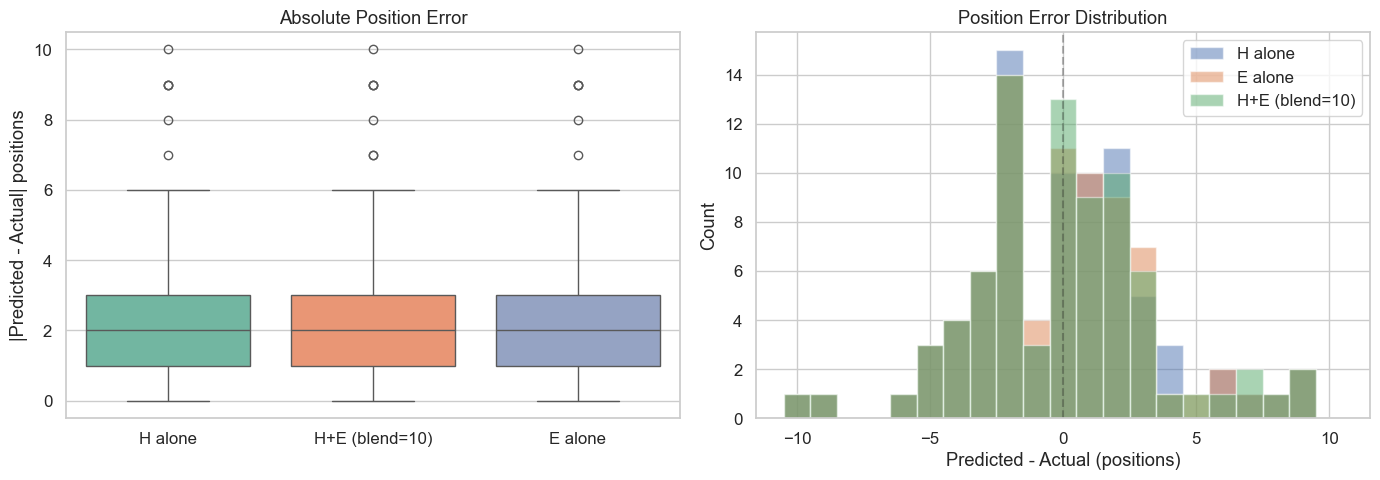

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = ['H alone', 'E alone', 'H+E (blend=10)']
plot_df = df[df['model'].isin(models_to_plot)]

# Box plot
sns.boxplot(data=plot_df, x='model', y='abs_error', ax=axes[0], palette='Set2')
axes[0].set_title('Absolute Position Error')
axes[0].set_xlabel('')
axes[0].set_ylabel('|Predicted - Actual| positions')

# Histogram
for model in models_to_plot:
    m_df = plot_df[plot_df['model'] == model]
    axes[1].hist(m_df['error'], bins=np.arange(-10.5, 11.5, 1), alpha=0.5, label=model)
axes[1].set_title('Position Error Distribution')
axes[1].set_xlabel('Predicted - Actual (positions)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].axvline(0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Predicted vs Actual scatter

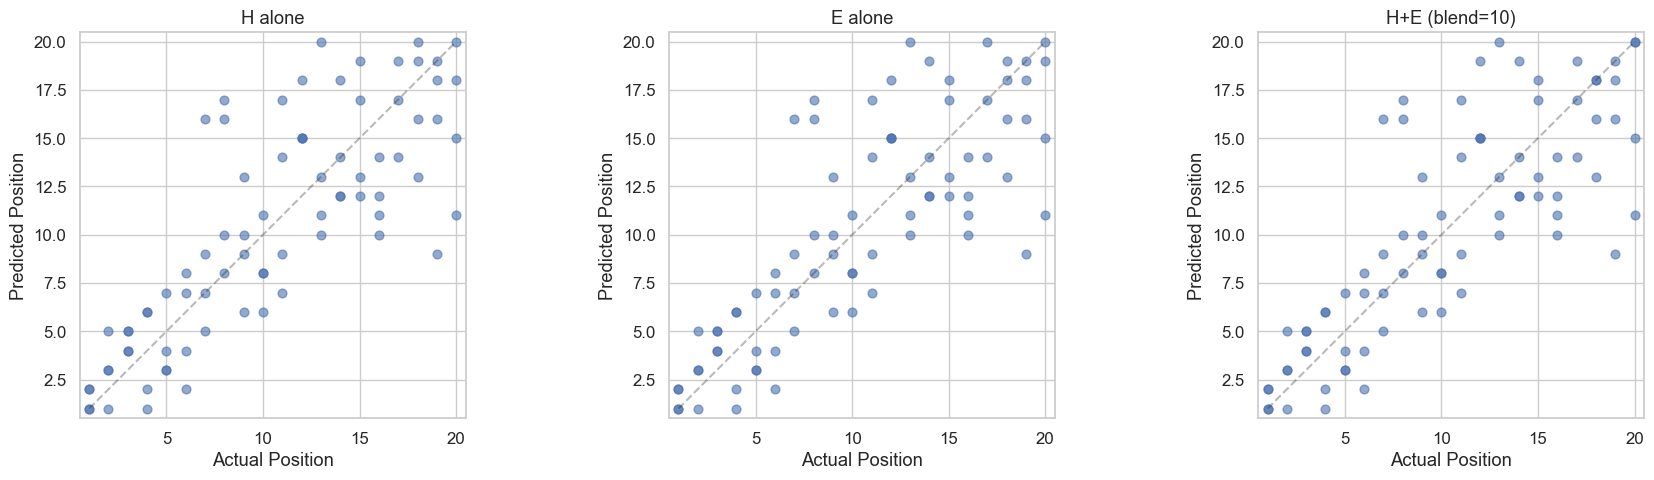

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes, models_to_plot, strict=True):
    m_df = plot_df[plot_df['model'] == model]
    ax.scatter(m_df['actual_pos'], m_df['predicted_pos'], alpha=0.6, s=40)
    ax.plot([1, 20], [1, 20], 'k--', alpha=0.3)
    ax.set_xlabel('Actual Position')
    ax.set_ylabel('Predicted Position')
    ax.set_title(model)
    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 20.5)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Per-race position comparison (H vs H+E)

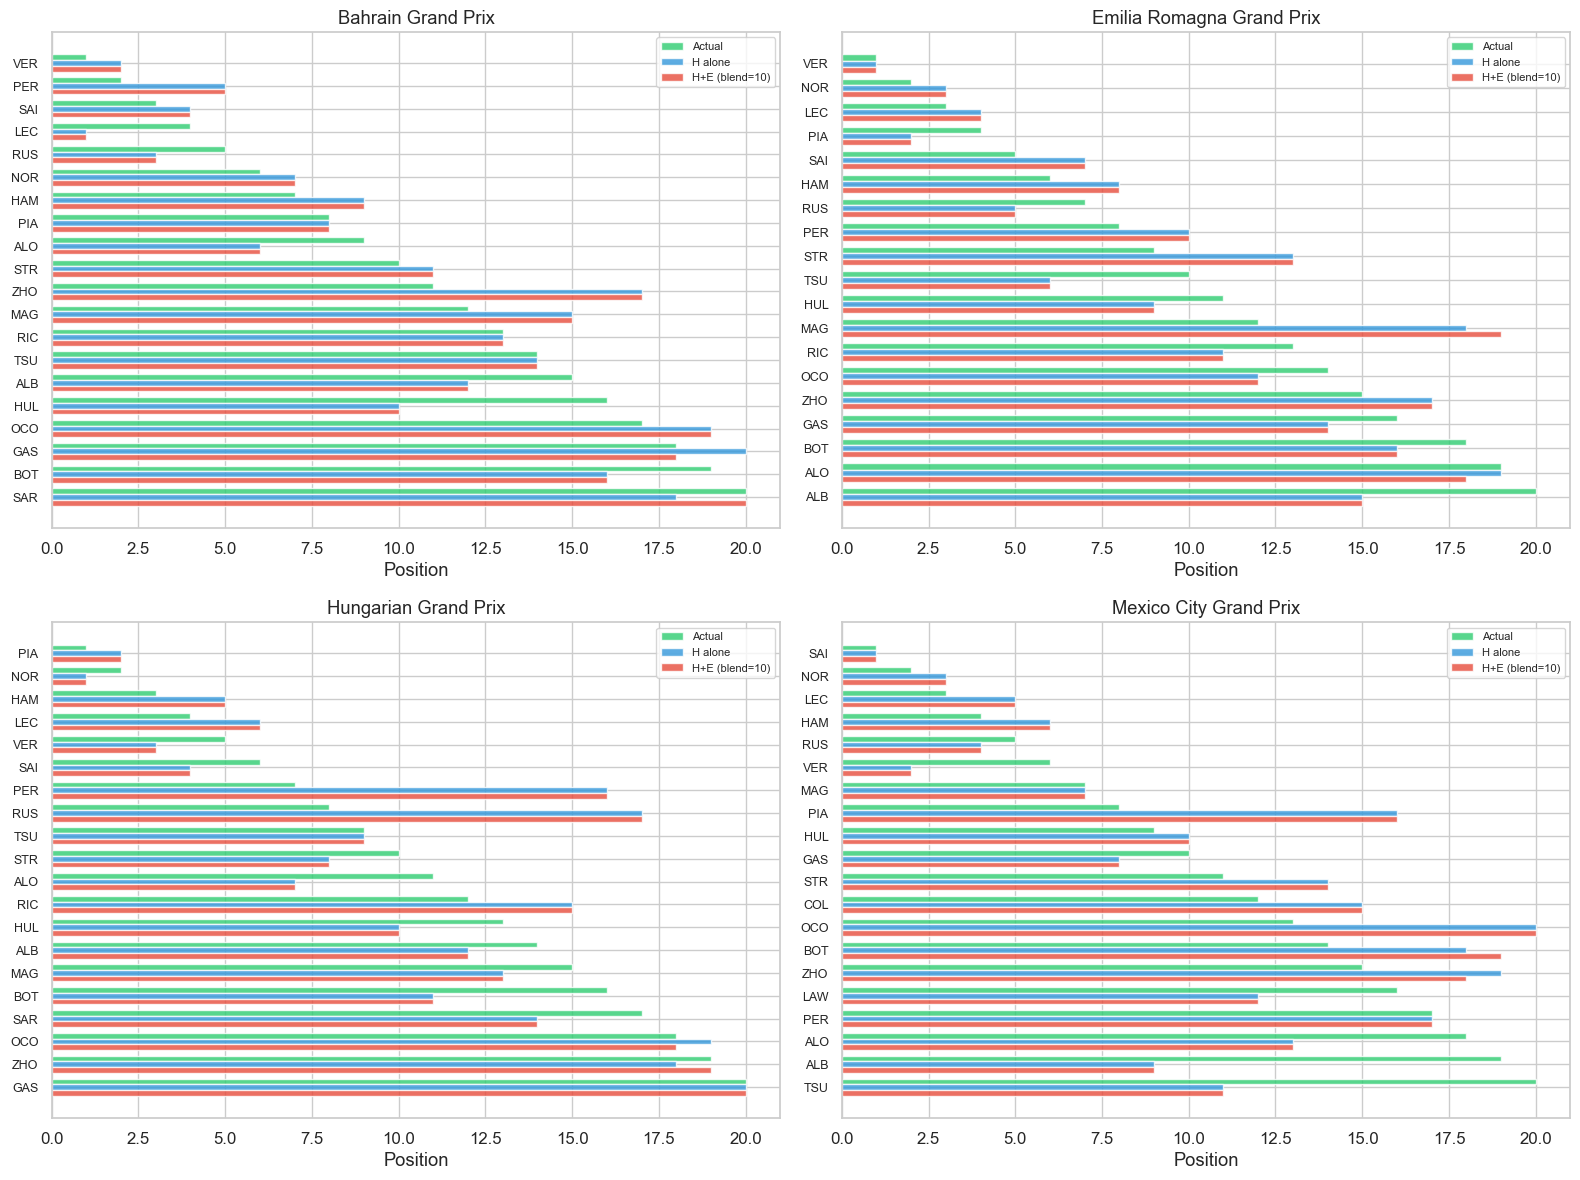

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, ev in zip(axes.flat, TEST_EVENTS, strict=True):
    ev_df = df[(df['event'] == ev) & (df['model'].isin(['H alone', 'H+E (blend=10)']))]

    h_df = ev_df[ev_df['model'] == 'H alone'].sort_values('actual_pos')
    e_df = ev_df[ev_df['model'] == 'H+E (blend=10)'].sort_values('actual_pos')

    drivers = h_df['driver'].values
    x = np.arange(len(drivers))
    width = 0.25

    ax.barh(x - width, h_df['actual_pos'].values, width, label='Actual', color='#2ecc71', alpha=0.8)
    ax.barh(x, h_df['predicted_pos'].values, width, label='H alone', color='#3498db', alpha=0.8)
    ax.barh(x + width, e_df['predicted_pos'].values, width, label='H+E (blend=10)', color='#e74c3c', alpha=0.8)

    ax.set_yticks(x)
    ax.set_yticklabels(drivers, fontsize=9)
    ax.set_xlabel('Position')
    ax.set_title(ev)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Feature importance: what E sees from H

Examine the proxy collapse — how many unique feature values does E actually get?

In [10]:
# Show meta-features for one race to illustrate proxy collapse
drivers_input, _ = build_race_data(TEST_EVENTS[0])
h_result = h_sim.simulate(TEST_EVENTS[0], drivers_input)
ens = EnsembleSimulator(h_sim, model_e, blend_laps=0)
meta = ens.compute_meta_features(h_result, ens._build_qualifying_data(drivers_input))

feature_cols = ['A_last', 'A_mean', 'A_std', 'A_min', 'A_range', 'A_last5',
                'B_last', 'B_mean', 'B_std', 'B_last5', 'C_pred',
                'grid_position', 'quali_delta_to_pole']

# Check which features are identical (proxy collapse)
print('Proxy collapse check (Bahrain 2024):')
print(f"  A_last == B_last: {(meta['A_last'] == meta['B_last']).all()}")
print(f"  A_mean == B_mean: {(meta['A_mean'] == meta['B_mean']).all()}")
print(f"  A_std  == B_std:  {(meta['A_std'] == meta['B_std']).all()}")
print(f"  A_last5== B_last5:{(meta['A_last5'] == meta['B_last5']).all()}")
print(f"  A_last == C_pred: {(meta['A_last'] == meta['C_pred']).all()}")
print(f'\n  -> 13 features collapse to {len(set(feature_cols)) - 4} unique + grid_position + quali_delta')

display(meta[['driver'] + feature_cols].round(2))

Proxy collapse check (Bahrain 2024):
  A_last == B_last: True
  A_mean == B_mean: True
  A_std  == B_std:  True
  A_last5== B_last5:True
  A_last == C_pred: True

  -> 13 features collapse to 9 unique + grid_position + quali_delta


,driver,A_last,A_mean,A_std,A_min,A_range,A_last5,B_last,B_mean,B_std,B_last5,C_pred,grid_position,quali_delta_to_pole
0,VER,2.0,2.00,0.00,2.0,0.0,2.0,2.0,2.00,0.00,2.0,2.0,1,0.01
1,LEC,1.0,1.00,0.00,1.0,0.0,1.0,1.0,1.00,0.00,1.0,1.0,2,0.00
2,RUS,3.0,3.00,0.00,3.0,0.0,3.0,3.0,3.00,0.00,3.0,3.0,3,0.32
3,SAI,4.0,4.00,0.00,4.0,0.0,4.0,4.0,4.00,0.00,4.0,4.0,4,0.34
4,PER,5.0,5.00,0.00,5.0,0.0,5.0,5.0,5.00,0.00,5.0,5.0,5,0.37
5,ALO,6.0,6.00,0.00,6.0,0.0,6.0,6.0,6.00,0.00,6.0,6.0,6,0.38
6,NOR,7.0,7.00,0.00,7.0,0.0,7.0,7.0,7.00,0.00,7.0,7.0,7,0.45
7,PIA,8.0,8.00,0.00,8.0,0.0,8.0,8.0,8.00,0.00,8.0,8.0,8,0.52
8,HAM,9.0,9.00,0.00,9.0,0.0,9.0,9.0,9.00,0.00,9.0,9.0,9,0.55
9,HUL,10.0,10.00,0.00,10.0,0.0,10.0,10.0,10.00,0.00,10.0,10.0,10,0.69


## 10. Conclusion

**Finding:** The H+E ensemble provides **no meaningful improvement** over H alone.

| Metric | H alone | E alone | H+E (blend=10) |
|--------|---------|---------|------------------|
| RMSE | 3.50 | 3.50 | 3.51 |
| Spearman | 0.816 | 0.816 | 0.815 |
| Within 3 | 75.9% | 77.2% | 77.2% |

**Root cause:** A/B proxy collapse. H produces a single position output per lap, so A and B proxy features are identical (13 → 9 unique features). C_pred also equals A_last. Model E trained on independent A, B, C models can differentiate; with H proxies, it cannot.

**Decision:** Default to `blend_laps=0` (H alone) for deployment. The API still supports configurable blend_laps for experimentation.